In [1]:
import pandas as pd 
import sklearn as sk
import os
import pandas as pd
import numpy as np 
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score



In [2]:
csv_path='NT_GNN_vanilla/'
grafo_path='Graphs/grafo_filtrato_undirect_small.csv'

grafo=pd.read_csv(grafo_path)
geni=grafo['source'].unique()

In [3]:
train_id=['filtered_CRC0327_NT_2.csv','filtered_CRC0542_NT72h_1.csv','filtered_CRC1620_NT_1.csv','filtered_CRC1139_NT_1.csv']
test_id=['filtered_CRC0322_NT_1_3000.csv','filtered_CRC1502_NT_1.csv']
kras=['CRC1502','CRC1620','CRC1139']
wt=['CRC0322','CRC0327','CRC0542']
train=pd.DataFrame()
test=pd.DataFrame()
for file in os.listdir(csv_path):
    sample_name=str.split(file,sep='_')[1]
    data=pd.read_csv(os.path.join(csv_path,file),header=0,index_col=0)
    valid_geni=[g for g in geni if g in data.columns]
    data=data.loc[:,valid_geni]
    data['sample']=sample_name
    data['cell_id']=data.index
    data.reset_index(drop=True,inplace=True)
    if sample_name in kras:
        data['label']=1
    else:
        data['label']=0
    if file in train_id:
        print('train') 
        train=pd.concat([train,data])
    else:
        print('test')
        test=pd.concat([test,data])
    

test
train
test
train
train
train


In [4]:
geni_senza_na = train.columns[train.isnull().sum() == 0]
print(f"Geni senza NaN nel train: {len(geni_senza_na)}")
geni_senza_na_test = test.columns[test.isnull().sum() == 0]
print(f"Geni senza NaN nel test: {len(geni_senza_na_test)}")

geni = [g for g in geni if g in train.columns]
geni_validi = [
    g for g in geni
    if g in train.columns and g in test.columns and
    train[g].isnull().sum() == 0 and test[g].isnull().sum() == 0
]

#filtro geni con na
meta_col = [c for c in ['label', 'sample', 'cell_id'] if c in train.columns]
train = train[geni_validi + meta_col]
test = test[geni_validi + meta_col]

Geni senza NaN nel train: 935
Geni senza NaN nel test: 941


In [5]:
#separo metadati e dato numerico
Y_train=train['label']
X_train=train[geni_validi]
Y_test=test['label']
X_test=test[geni_validi]

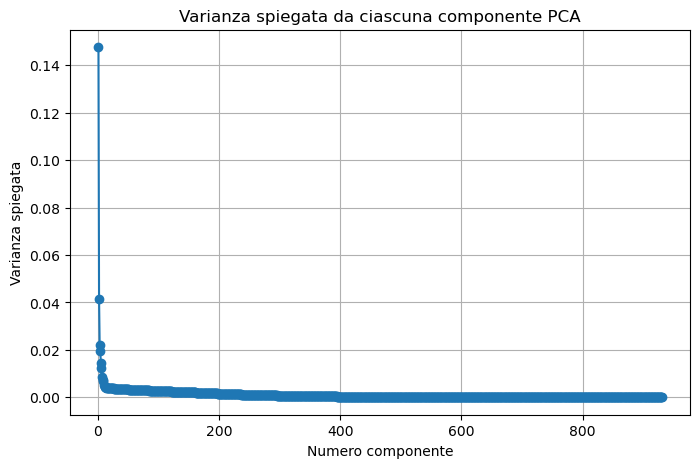

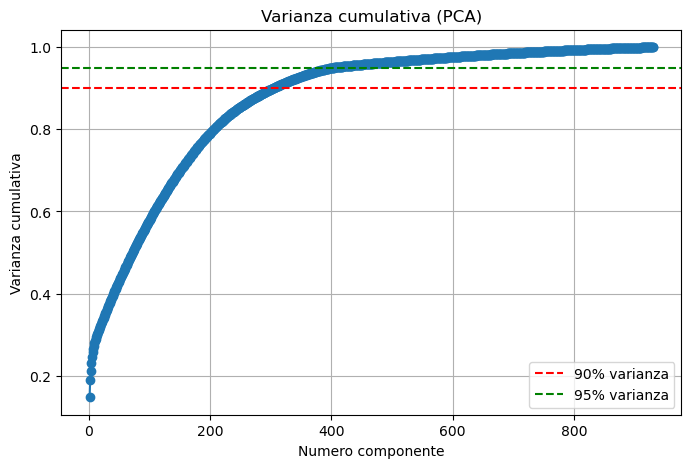

In [6]:
#standardizzo e faccio PCA
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)

# Varianza spiegata da ogni componente
explained_var = pca.explained_variance_ratio_
cumulative_var = explained_var.cumsum()
#varianza spiegata asse y max 1
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_var)+1), explained_var, marker='o')
plt.title('Varianza spiegata da ciascuna componente PCA')
plt.xlabel('Numero componente')
plt.ylabel('Varianza spiegata')
plt.grid(True)
plt.show()

#varianza cumulativa
cumulative_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, marker='o')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% varianza')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% varianza')
plt.xlabel('Numero componente')
plt.ylabel('Varianza cumulativa')
plt.title('Varianza cumulativa (PCA)')
plt.grid(True)
plt.legend()
plt.show()

In [7]:
import numpy as np


n_components_90 = np.argmax(cumulative_var >= 0.90) + 1

print(f"Componenti per spiegare ≥90% della varianza: {n_components_90}")


Componenti per spiegare ≥90% della varianza: 304


In [8]:
import numpy as np

# Verifica se ci sono NaN totali
print("Ci sono NaN nel test standardizzato?", np.isnan(X_train_scaled).any())

# Quante colonne contengono NaN
na_col_mask = np.isnan(X_train_scaled).any(axis=0)
print(f"Numero di colonne con NaN: {np.sum(na_col_mask)}")

Ci sono NaN nel test standardizzato? False
Numero di colonne con NaN: 0


In [9]:
pca = PCA(n_components=n_components_90)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca=pca.transform(X_test_scaled)

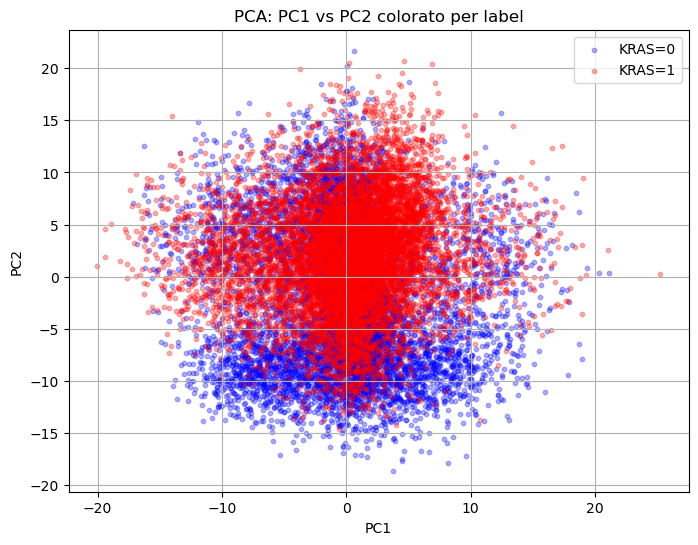

In [10]:
import matplotlib.pyplot as plt

train_pca_df = pd.DataFrame(
    X_train_pca[:,[4,2]],
    columns=["PC1", "PC2"]
)
train_pca_df["label"] = Y_train.values
train_pca_df["sample"] = train["sample"].values

# Plot
plt.figure(figsize=(8,6))
for lbl, color in zip([0,1], ["blue", "red"]):
    subset = train_pca_df[train_pca_df["label"] == lbl]
    plt.scatter(subset["PC1"], subset["PC2"],
                c=color, label=f"KRAS={lbl}", alpha=0.3, s=10)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA: PC1 vs PC2 colorato per label")
plt.legend()
plt.grid(True)
plt.show()


In [101]:
#SVM 
param_grid_rbf = {
    'C': [0.01, 0.1, 1, 5],
    'gamma': [0.001, 0.01, 0.1, 1, 'scale']
}

svm_rbf = SVC(kernel='rbf')
grid_rbf = GridSearchCV(svm_rbf, param_grid_rbf, cv=3, scoring='f1', verbose=3,n_jobs=3)
grid_rbf.fit(X_train_pca, Y_train)




Fitting 3 folds for each of 20 candidates, totalling 60 fits


AttributeError: 'GridSearchCV' object has no attribute 'best_params_'

In [102]:
print("Migliori parametri trovati:", grid_rbf.best_params_)
print(f"Score migliore in CV: {grid_rbf.best_score_:.3f}")

Migliori parametri trovati: {'C': 5, 'gamma': 'scale'}
Score migliore in CV: 0.980


In [106]:
best_model = grid_rbf.best_estimator_
y_pred = best_model.predict(X_test_pca)

print("\nReport test set:")
print(classification_report(Y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(Y_test, y_pred))



Report test set:
              precision    recall  f1-score   support

           0       0.48      0.98      0.64      3000
           1       0.97      0.41      0.58      5498

    accuracy                           0.61      8498
   macro avg       0.72      0.70      0.61      8498
weighted avg       0.80      0.61      0.60      8498

Confusion Matrix:
[[2936   64]
 [3220 2278]]


/tmp/ipykernel_903662/327148640.py:4: FutureWarning: In a future version, the Index constructor will not infer numeric dtypes when passed object-dtype sequences (matching Series behavior)
  pivot_table = results.pivot(index='param_gamma', columns='param_C', values='mean_test_score')


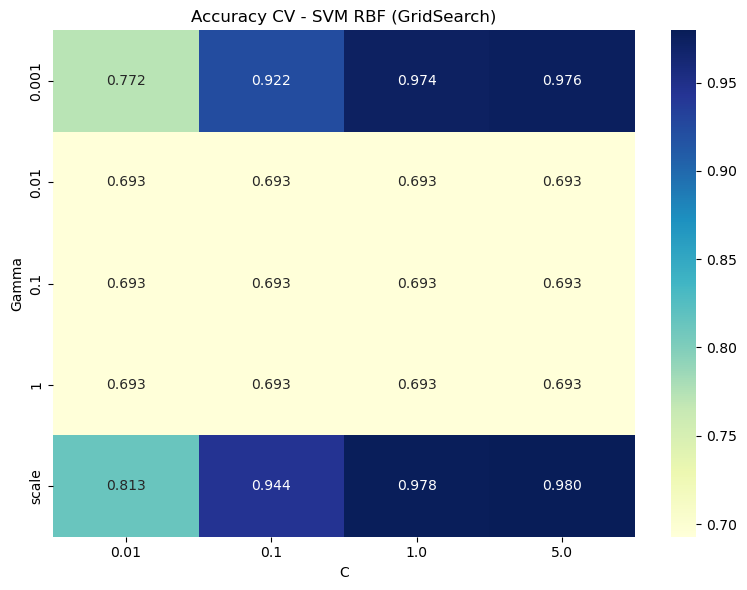

In [108]:

results = pd.DataFrame(grid_rbf.cv_results_)

# Costruisci una tabella righe = gamma, colonne = C
pivot_table = results.pivot(index='param_gamma', columns='param_C', values='mean_test_score')

plt.figure(figsize=(8,6))
sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Accuracy CV - SVM RBF (GridSearch)")
plt.xlabel("C")
plt.ylabel("Gamma")
plt.tight_layout()
plt.show()


In [11]:
svm_prova = SVC(kernel='rbf',C=0.01,gamma='scale')
svm_prova.fit(X_train,Y_train)
pred=svm_prova.predict(X_test)
print("\nReport test set:")
print(classification_report(Y_test, pred))

print("Confusion Matrix:")
print(confusion_matrix(Y_test, pred))



Report test set:
              precision    recall  f1-score   support

           0       0.47      0.91      0.62      3000
           1       0.90      0.45      0.60      5498

    accuracy                           0.61      8498
   macro avg       0.69      0.68      0.61      8498
weighted avg       0.75      0.61      0.61      8498

Confusion Matrix:
[[2718  282]
 [3028 2470]]


Random forest

In [12]:
X_train = train[geni_validi]
y_train = train["label"]

X_test = test[geni_validi]
y_test = test["label"]


In [18]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200,500],
    'max_depth': [10, 50, None],
    'max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, n_jobs=6,)
grid.fit(X_train, y_train)

print("Migliori parametri:", grid.best_params_)


Migliori parametri: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 500}


In [19]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

print("\nReport test set:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Report test set:
              precision    recall  f1-score   support

           0       0.45      0.97      0.61      3000
           1       0.96      0.34      0.50      5498

    accuracy                           0.56      8498
   macro avg       0.70      0.66      0.56      8498
weighted avg       0.78      0.56      0.54      8498

Confusion Matrix:
[[2920   80]
 [3624 1874]]


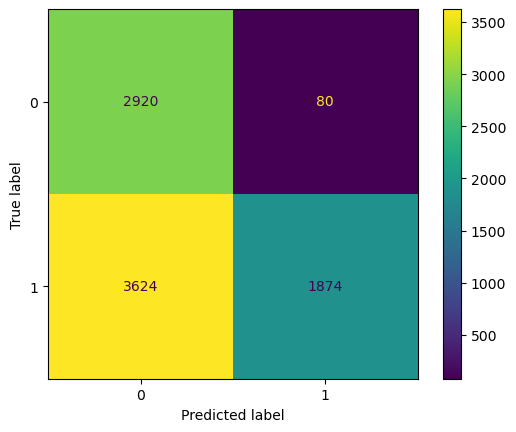

In [22]:
from sklearn.metrics import ConfusionMatrixDisplay
cm=confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [16]:
results = pd.DataFrame(grid.cv_results_)

In [17]:
results

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_max_features,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,13.315170,0.209282,0.120731,0.014698,10,sqrt,100,"{'max_depth': 10, 'max_features': 'sqrt', 'n_e...",0.903059,0.987383,0.968718,0.953053,0.036163,10
1,26.438493,0.314516,0.204279,0.004951,10,sqrt,200,"{'max_depth': 10, 'max_features': 'sqrt', 'n_e...",0.907897,0.987038,0.968890,0.954608,0.033851,9
2,4.361835,0.067487,0.124119,0.003088,10,log2,100,"{'max_depth': 10, 'max_features': 'log2', 'n_e...",0.910662,0.984791,0.950052,0.948502,0.030283,11
3,8.674958,0.046335,0.244084,0.001789,10,log2,200,"{'max_depth': 10, 'max_features': 'log2', 'n_e...",0.906687,0.984618,0.950743,0.947350,0.031905,12
4,16.024725,0.226272,0.128126,0.012592,50,sqrt,100,"{'max_depth': 50, 'max_features': 'sqrt', 'n_e...",0.912044,0.989284,0.972174,0.957834,0.033123,6
5,31.943189,0.703009,0.236017,0.006698,50,sqrt,200,"{'max_depth': 50, 'max_features': 'sqrt', 'n_e...",0.917401,0.987902,0.972174,0.959159,0.030217,2
6,5.303396,0.157971,0.149644,0.004222,50,log2,100,"{'max_depth': 50, 'max_features': 'log2', 'n_e...",0.920511,0.987383,0.963705,0.957200,0.027685,8
7,10.721009,0.131926,0.287757,0.005123,50,log2,200,"{'max_depth': 50, 'max_features': 'log2', 'n_e...",0.921894,0.987729,0.965607,0.958410,0.027355,3
8,15.953955,0.246022,0.119432,0.004235,None,sqrt,100,"{'max_depth': None, 'max_features': 'sqrt', 'n...",0.912044,0.988939,0.972174,0.957719,0.033014,7
9,32.102441,0.745088,0.218000,0.006558,None,sqrt,200,"{'max_depth': None, 'max_features': 'sqrt', 'n...",0.917401,0.988247,0.972174,0.959274,0.030327,1
